# Case 2 — OTT Viewer Retention: Diagnosing Engagement Patterns
**Winter Consulting Capstone, Consulting & Analytics Club, IIT Guwahati**

**Business question:** viewers disengage during Season 1 of original series. The platform wants to know: (1) why viewers drop off, (2) which factors matter most, (3) what content/product changes would help.

**Data note:** the case links a real episode-level engagement dataset that isn't reachable in this environment. `src/data_generation/generate_ott_data.py` builds a structurally identical synthetic dataset (same column design: pacing, cognitive load, episode structure, drop-off outcomes) with a deliberately embedded ground-truth signal, so the modeling below has real relationships to recover rather than random noise.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import pandas as pd
from data_generation.generate_ott_data import generate
df = generate()
df.head()

Saved 320 rows -> /home/claude/consulting-portfolio/data/raw/ott_episode_engagement.csv


,series_id,genre,episode_number,pacing_score,cognitive_load_score,runtime_min,cliffhanger_ending,new_character_introduced,recap_provided,avg_watch_pct,viewers_start_of_episode,viewers_completed_episode,dropoff_rate,dropoff_flag
0,1,SciFi,1,5.08,4.68,34.1,True,False,False,0.726,716062,600540,0.1613,0
1,1,SciFi,2,7.07,5.69,34.6,False,False,False,0.745,600540,545762,0.0912,0
2,1,SciFi,3,4.44,2.18,40.1,False,True,True,0.778,545762,515350,0.0557,0
3,1,SciFi,4,5.64,5.41,42.9,False,False,True,0.623,515350,398054,0.2276,1
4,1,SciFi,5,8.20,4.05,41.7,False,True,True,0.753,398053,334039,0.1608,0


## 1. EDA — where in the season do viewers drop off?

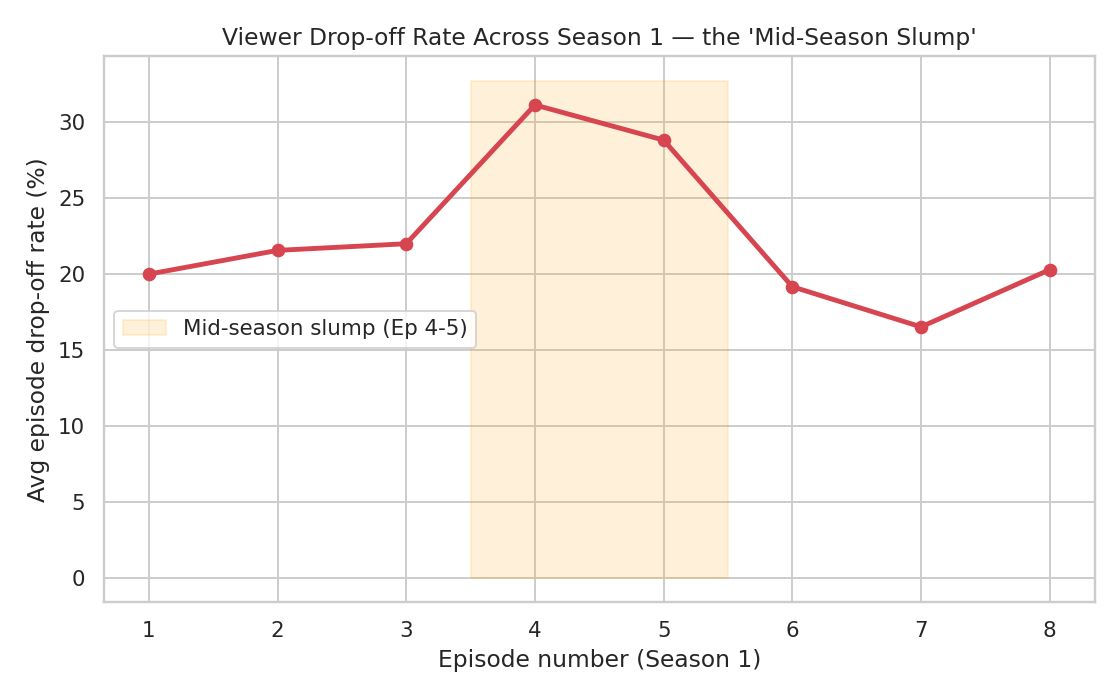

In [2]:
from case2_ott.eda import load, fig1_dropoff_by_episode, fig2_correlation_heatmap, fig3_pacing_cogload_scatter, fig4_genre_comparison
df = load()
fig1_dropoff_by_episode(df)
from IPython.display import Image, display
display(Image('../reports/figures/case2_dropoff_by_episode.png'))

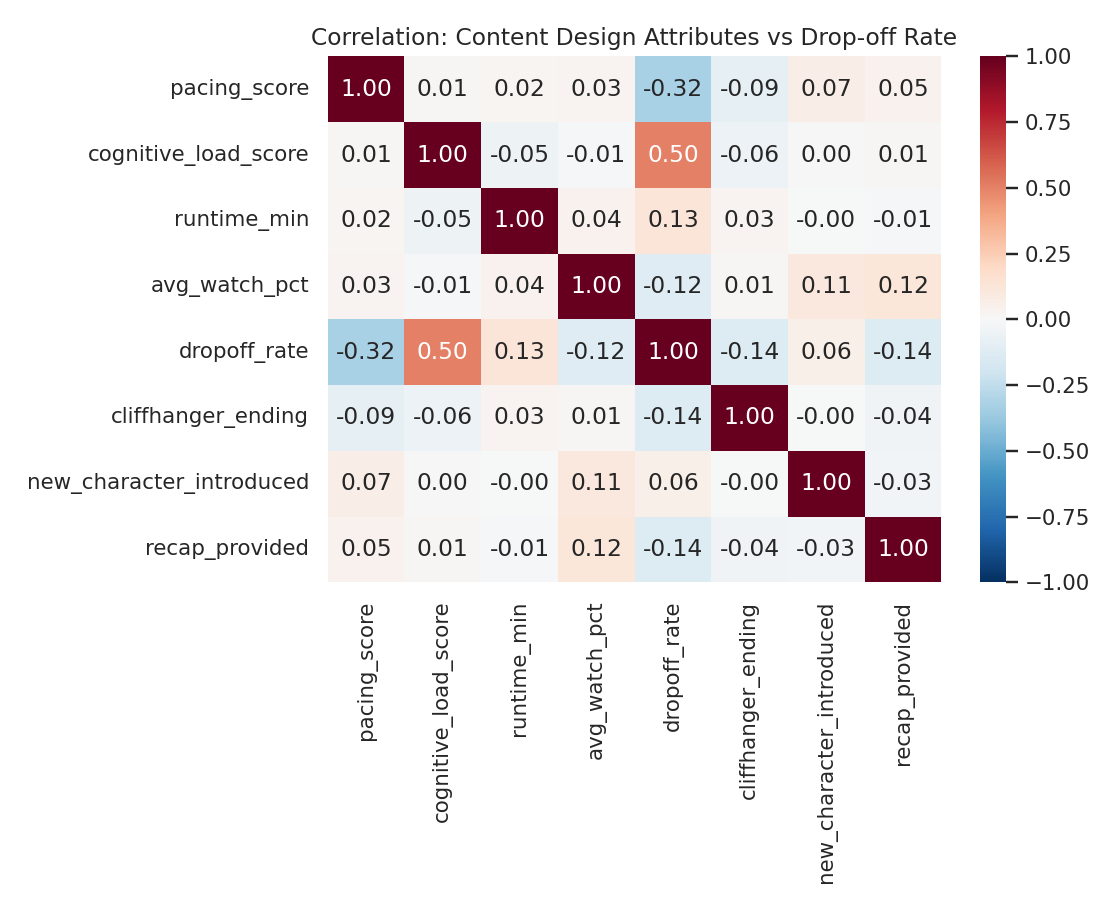

In [3]:
fig2_correlation_heatmap(df)
display(Image('../reports/figures/case2_correlation_heatmap.png'))

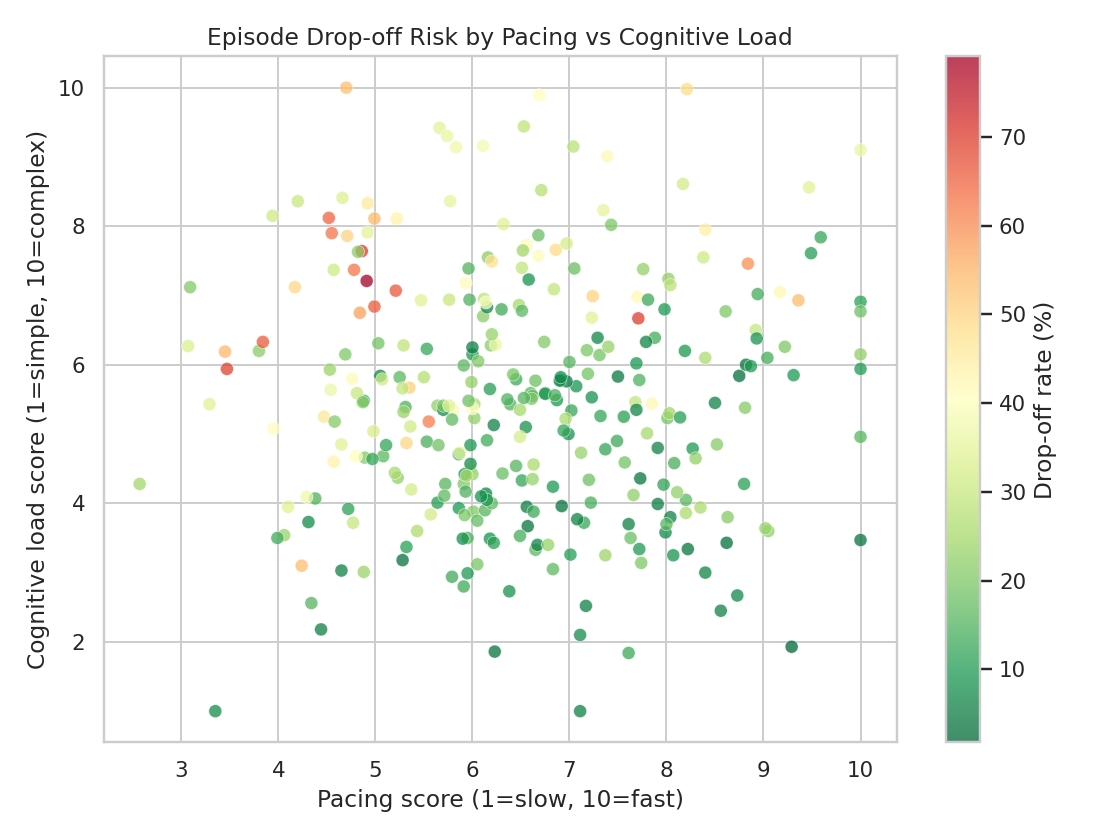

In [4]:
fig3_pacing_cogload_scatter(df)
display(Image('../reports/figures/case2_pacing_cogload_scatter.png'))

## 2. Which factors have the greatest impact on drop-off risk?
A gradient-boosted classifier predicts whether an episode is a high-drop-off-risk episode (above platform median); SHAP explains *why* per-feature.

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Case 2 Model] Test ROC-AUC: 0.771
              precision    recall  f1-score   support

           0       0.71      0.68      0.69        40
           1       0.69      0.72      0.71        40

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80




Top drivers of drop-off risk (mean |SHAP|):
cognitive_load_score        1.276901
pacing_score                0.993957
avg_watch_pct               0.639338
episode_number              0.390802
new_character_introduced    0.306813
runtime_min                 0.296743
recap_provided              0.292572
cliffhanger_ending          0.127598
dtype: float64


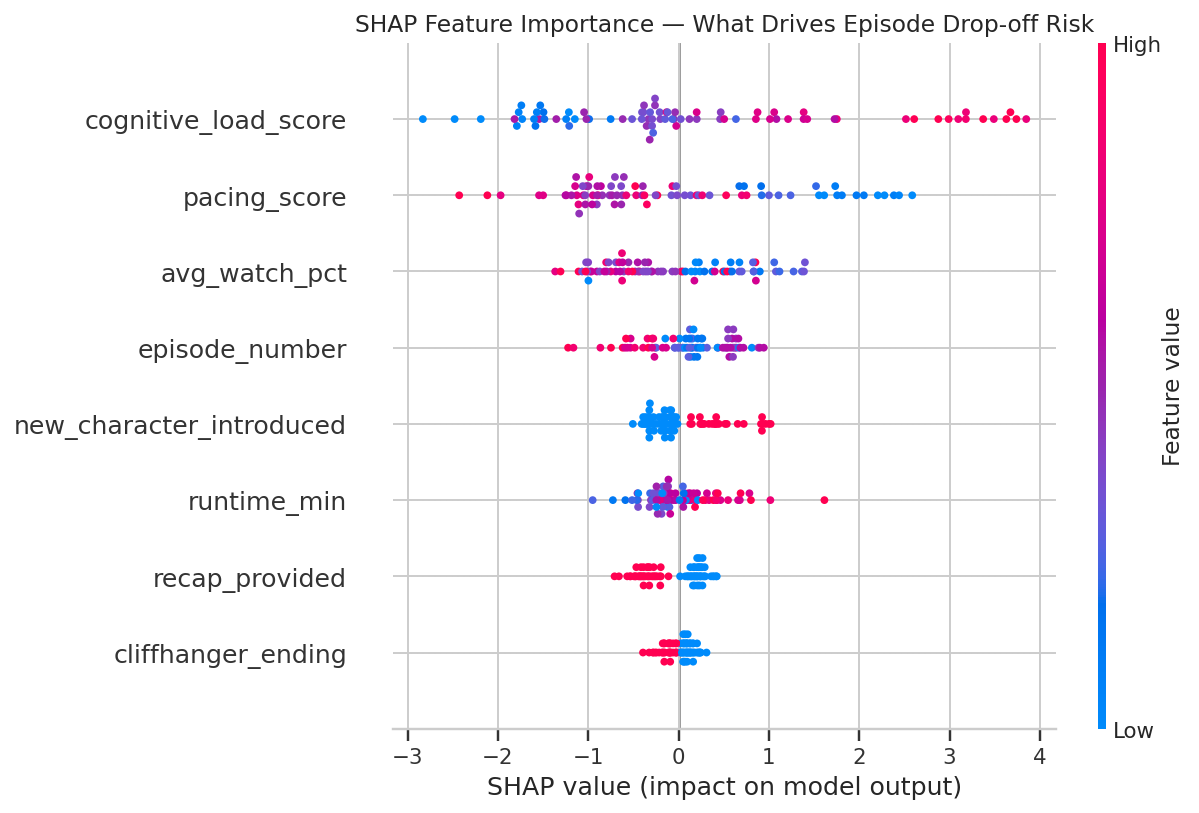

In [5]:
from case2_ott.churn_model import train
model, auc, mean_abs_shap = train()
display(Image('../reports/figures/case2_shap_summary.png'))

**Reading the SHAP plot:** high cognitive_load_score (red, right side) pushes drop-off risk up; high pacing_score (red, but on the *left*) pushes it down — faster episodes retain viewers better. This directly answers Key Question #2.

## 3. Can episodes be meaningfully segmented?

[Case 2 Segmentation] best_k=4
         n_episodes  avg_pacing  avg_cognitive_load  avg_runtime  \
segment                                                            
1                92        6.46                4.11        45.40   
3                78        6.05                5.17        31.33   
0                74        6.17                5.65        48.85   
2                76        7.41                7.24        41.41   

         avg_watch_pct  avg_dropoff_rate  
segment                                   
1                 0.71              0.19  
3                 0.80              0.19  
0                 0.89              0.23  
2                 0.71              0.29  


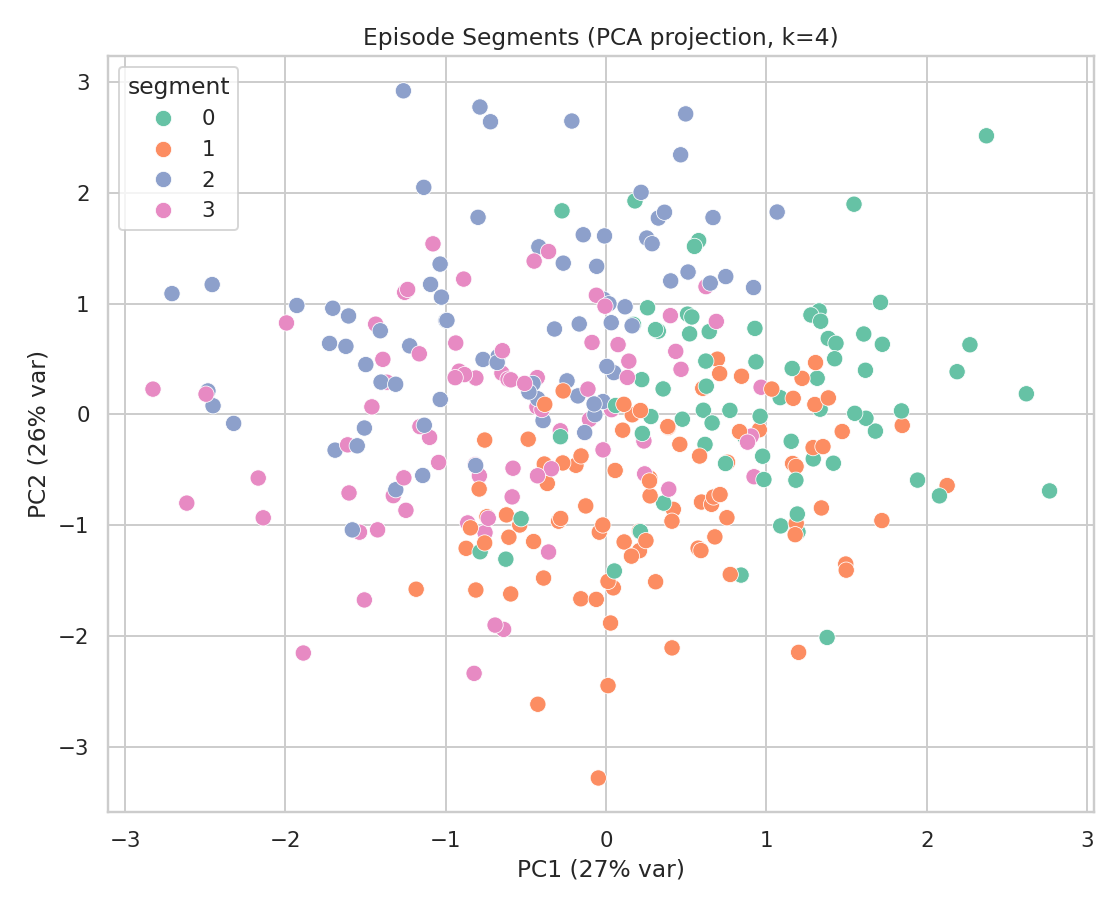

,n_episodes,avg_pacing,avg_cognitive_load,avg_runtime,avg_watch_pct,avg_dropoff_rate
segment,,,,,,
1,92,6.46,4.11,45.40,0.71,0.19
3,78,6.05,5.17,31.33,0.80,0.19
0,74,6.17,5.65,48.85,0.89,0.23
2,76,7.41,7.24,41.41,0.71,0.29


In [6]:
from case2_ott.segmentation import run as run_segmentation
seg_df, profile = run_segmentation()
display(Image('../reports/figures/case2_segments_pca.png'))
profile

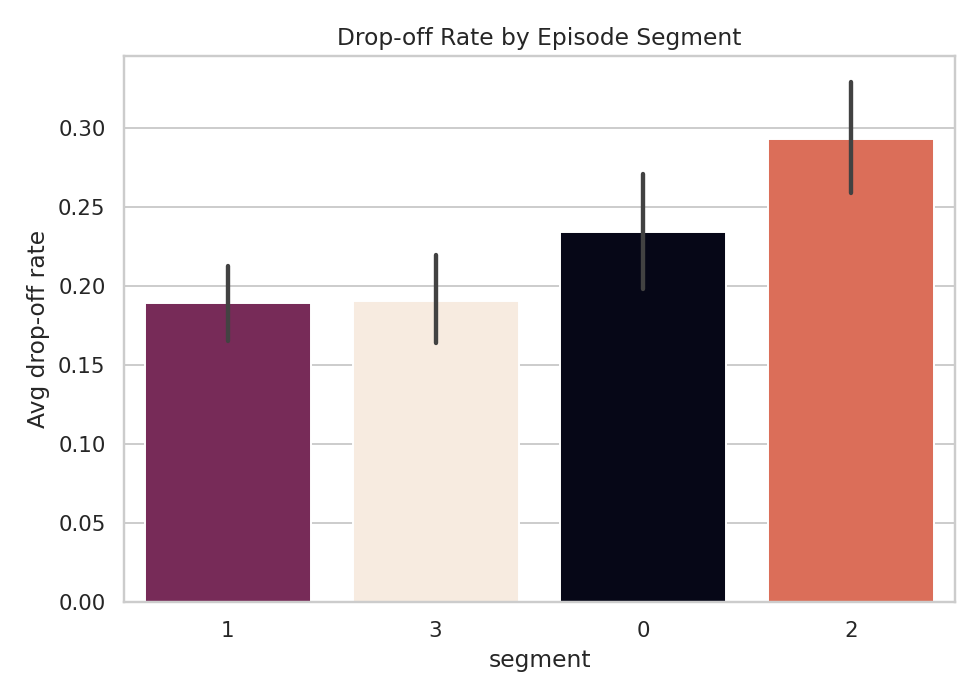

In [7]:
display(Image('../reports/figures/case2_segments_dropoff.png'))

## 4. Recommendation

**Primary action: editing/pacing review specifically for episodes 4-5** (the mid-season slump) — this is where the two dominant SHAP drivers (cognitive load, pacing) converge with the observed drop-off spike.

**Segment-level action:** the highest-drop-off cluster is slow-paced + high-cognitive-load + below-average watch-through-percentage episodes. Any future episode matching this profile should get a pacing/complexity review *before* release, not after viewership data confirms the problem.

**Prioritization:** pacing/cognitive-load edits are lower-cost and faster to ship than structural episode-count changes, so they're prioritized first; a recap-before-complex-episodes feature is a secondary, product-level lever (recap_provided shows a protective effect in the correlation heatmap).

**Risk:** over-simplifying pacing/complexity risks diluting creative quality — mitigated by scoping the recommendation to episodes 4-5 specifically rather than a blanket pacing mandate across the season.